#01- Exploratory Data Analysis

### 1: Mounting drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/capstone'
print(f"Working from: {BASE}")

Mounted at /content/drive
Working from: /content/drive/MyDrive/capstone


### 2: Seeds and config

In [ ]:
#Setting fixed seeds to ensure reprodcible results
import random
import numpy as np
import torch
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SUBSET_TRAIN = 4000
SUBSET_VAL   = 500
SUBSET_TEST  = 500
IMG_SIZE     = (224, 224)

print(f"Seed: {SEED} | Device: {DEVICE}")

Seed: 42 | Device: cuda


### 3: Installing required packages

In [ ]:
!pip install datasets==2.14.6 --quiet
!pip install transformers==4.40.0 --quiet
!pip install torch torchvision --quiet
!apt-get install -y tesseract-ocr tesseract-ocr-eng --quiet
!pip install pytesseract pillow opencv-python-headless --quiet
!pip install scikit-learn pandas matplotlib seaborn tqdm --quiet
print("All packages are installed.")

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
tesseract-ocr-eng is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
All packages installed.


### 4: Load Dataset

In [ ]:
#Streaming mode is used to avoid storage waste
from datasets import load_dataset

print("Loading RVL-CDIP...")

train_ds = load_dataset("rvl_cdip", split="train", streaming=True)
val_ds   = load_dataset("rvl_cdip", split="validation", streaming=True)
test_ds  = load_dataset("rvl_cdip", split="test", streaming=True)

train_list = list(train_ds.take(SUBSET_TRAIN))
val_list   = list(val_ds.take(SUBSET_VAL))
test_list  = list(test_ds.take(SUBSET_TEST))

LABEL_NAMES = ['letter', 'form', 'email', 'handwritten', 'advertisement',
               'scientific report', 'scientific publication', 'specification',
               'file folder', 'news article', 'budget', 'invoice',
               'presentation', 'questionnaire', 'resume', 'memo']
NUM_CLASSES = len(LABEL_NAMES)

print(f"Train: {len(train_list)} | Val: {len(val_list)} | Test: {len(test_list)}")
print(f"Classes: {NUM_CLASSES}")

Loading RVL-CDIP...
Train: 4000 | Val: 500 | Test: 500
Classes: 16


### 5: Import libraries

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from PIL import Image, ImageFilter
from collections import Counter

print("All imports are fine.")

All imports ok


### 6: Class Distribution Analysis

/tmp/ipykernel_6057/1117850869.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_dist['class'], rotation=45, ha='right', fontsize=9)


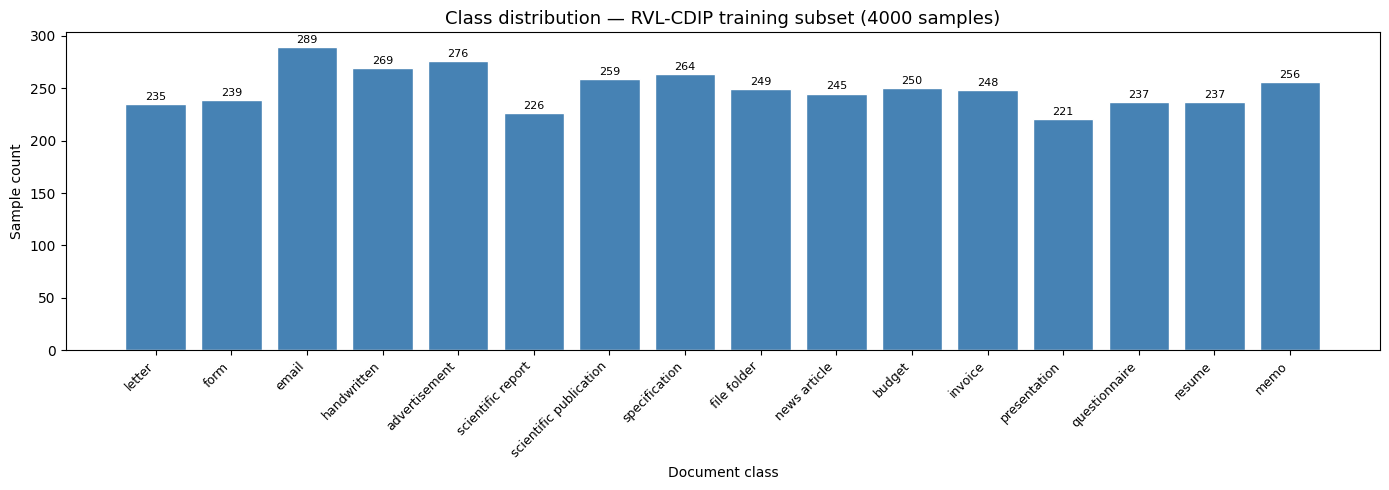

Class counts:
                 class  count
                letter    235
                  form    239
                 email    289
           handwritten    269
         advertisement    276
     scientific report    226
scientific publication    259
         specification    264
           file folder    249
          news article    245
                budget    250
               invoice    248
          presentation    221
         questionnaire    237
                resume    237
                  memo    256


In [ ]:
#Counting the training samples of each class
train_labels = [item['label'] for item in train_list]
label_counts = Counter(train_labels)

df_dist = pd.DataFrame({
    'class': [LABEL_NAMES[i] for i in sorted(label_counts.keys())],
    'count': [label_counts[i] for i in sorted(label_counts.keys())]
})

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(df_dist['class'], df_dist['count'],
              color='steelblue', edgecolor='white')
ax.set_title("Class distribution — RVL-CDIP training subset (4000 samples)",
             fontsize=13)
ax.set_xlabel("Document class")
ax.set_ylabel("Sample count")
ax.set_xticklabels(df_dist['class'], rotation=45, ha='right', fontsize=9)

for bar, count in zip(bars, df_dist['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(count), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/class_distribution.png", dpi=150)
plt.show()

print("Class counts:")
print(df_dist.to_string(index=False))

### 7: Image Resolution Analysis

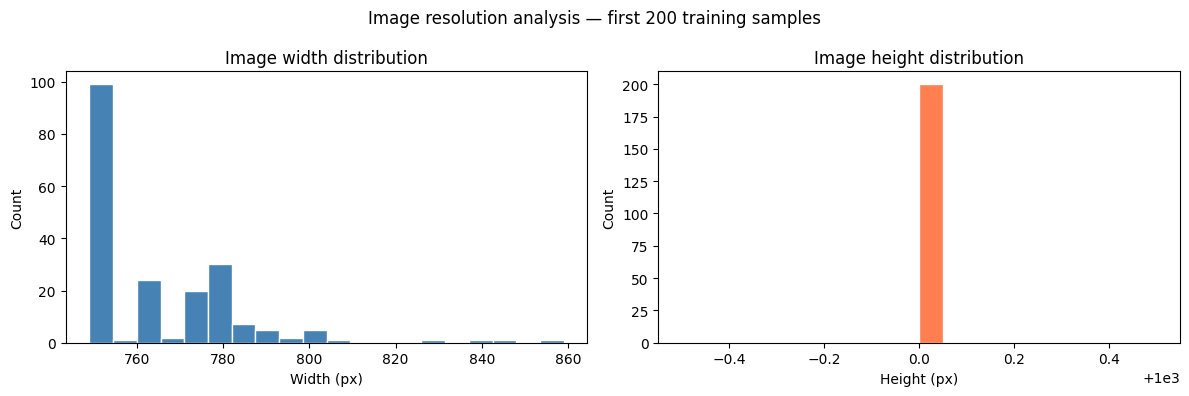

Average width  : 766 px
Average height : 1000 px
Min size       : 749x1000 px
Max size       : 859x1000 px


In [ ]:
#Image size distribution
widths, heights = [], []

for item in train_list[:200]:
    img = item['image']
    widths.append(img.width)
    heights.append(img.height)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(widths, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title("Image width distribution")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Count")

axes[1].hist(heights, bins=20, color='coral', edgecolor='white')
axes[1].set_title("Image height distribution")
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Count")

plt.suptitle("Image resolution analysis — first 200 training samples", fontsize=12)
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/image_sizes.png", dpi=150)
plt.show()

print(f"Average width  : {np.mean(widths):.0f} px")
print(f"Average height : {np.mean(heights):.0f} px")
print(f"Min size       : {min(widths)}x{min(heights)} px")
print(f"Max size       : {max(widths)}x{max(heights)} px")

### 8: Sample Images Per Class

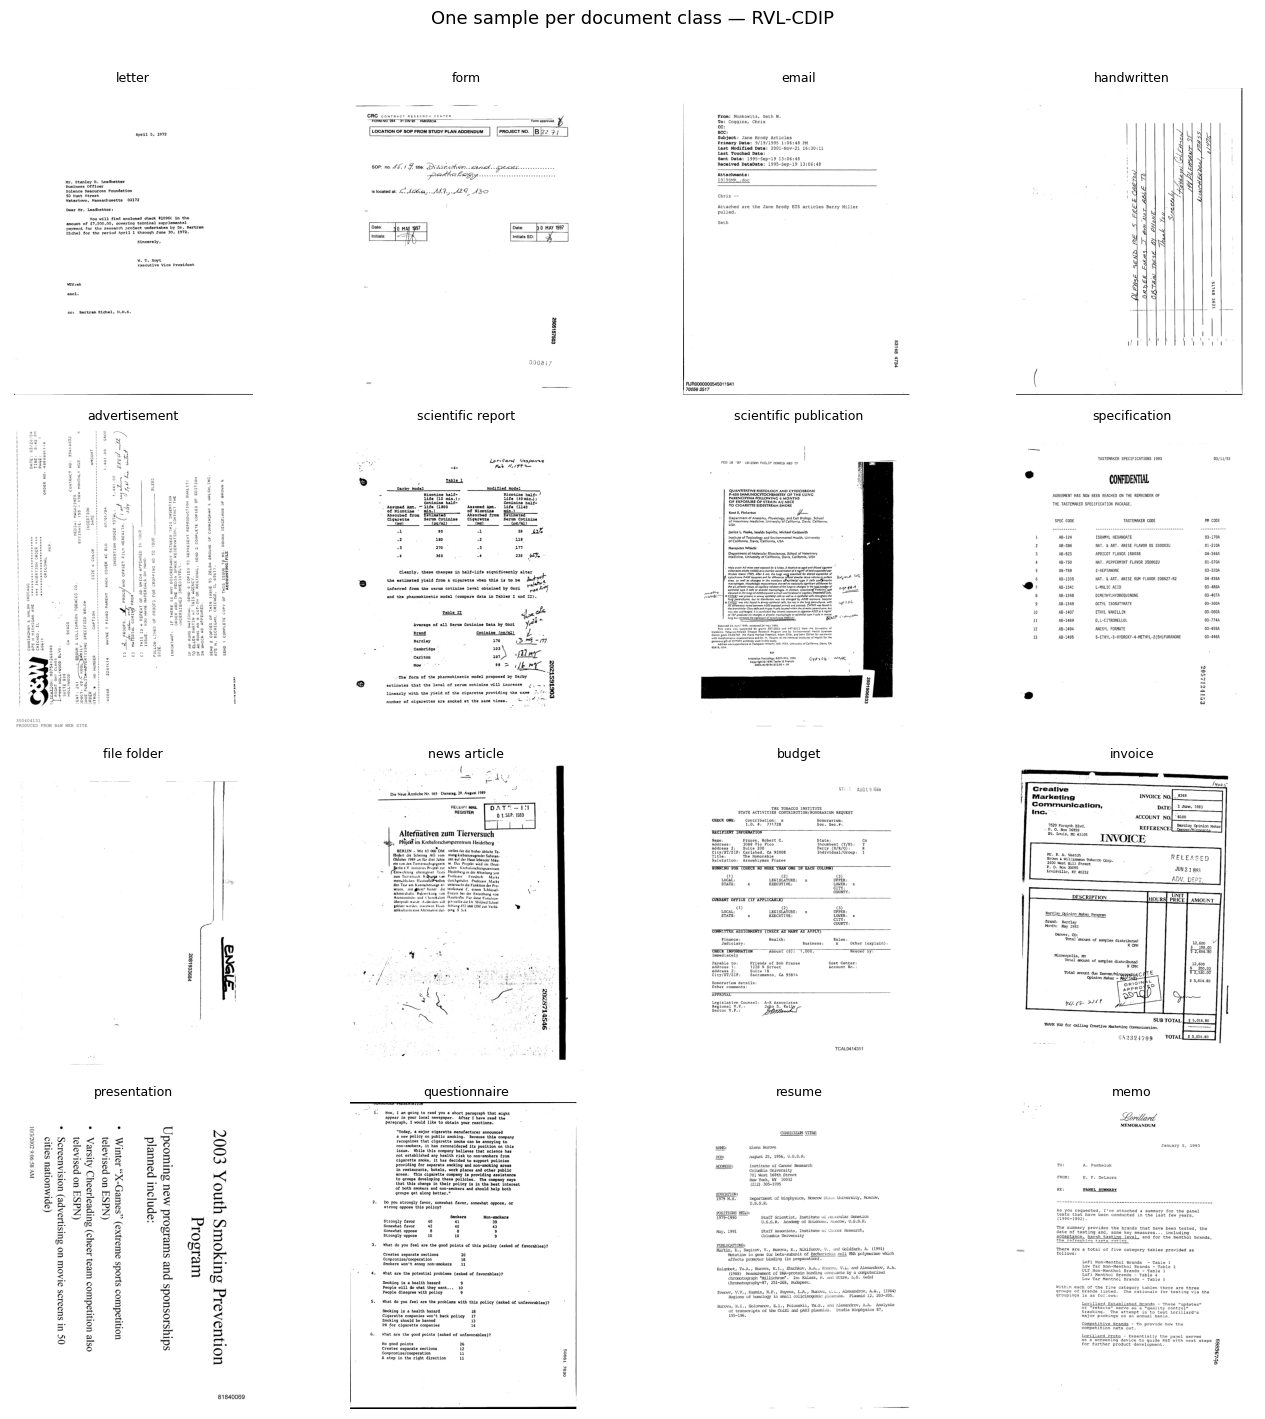

Sample grid saved.


In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for class_id, ax in enumerate(axes.flatten()):
    sample = next((item for item in train_list
                   if item['label'] == class_id), None)
    if sample:
        ax.imshow(sample['image'], cmap='gray')
        ax.set_title(LABEL_NAMES[class_id], fontsize=9, pad=4)
    else:
        ax.set_title(f"{LABEL_NAMES[class_id]} (not found)", fontsize=8)
    ax.axis('off')

plt.suptitle("One sample per document class — RVL-CDIP", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/sample_grid.png", dpi=150,
            bbox_inches='tight')
plt.show()
print("Sample grid saved.")

### 9: Image Quality Analysis

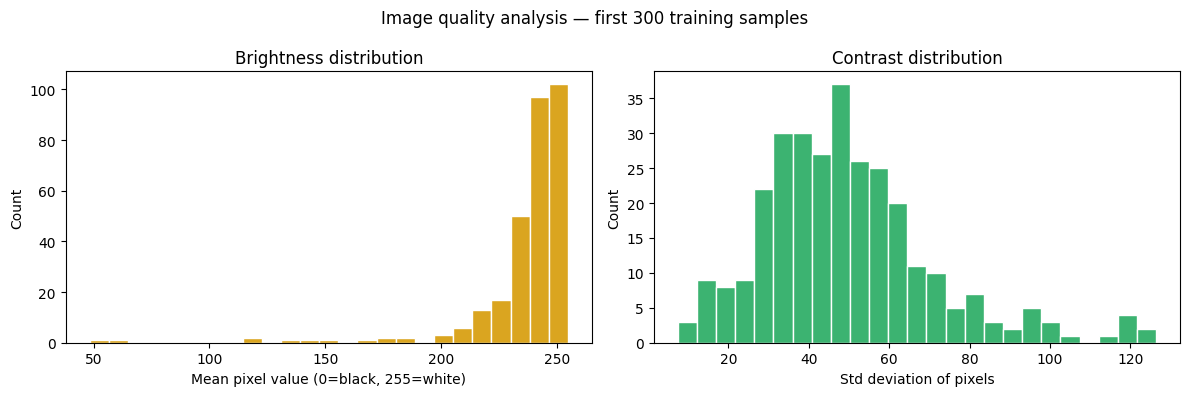

Avg brightness : 236.4
Avg contrast   : 49.6


In [ ]:
#Brightness = mean pixel value, Contrast = std deviation
#Low constrast samples can cause OCR errors
brightness_vals = []
contrast_vals   = []

for item in train_list[:300]:
    img_gray = item['image'].convert('L')
    arr = np.array(img_gray)
    brightness_vals.append(arr.mean())
    contrast_vals.append(arr.std())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(brightness_vals, bins=25, color='goldenrod', edgecolor='white')
axes[0].set_title("Brightness distribution")
axes[0].set_xlabel("Mean pixel value (0=black, 255=white)")
axes[0].set_ylabel("Count")

axes[1].hist(contrast_vals, bins=25, color='mediumseagreen', edgecolor='white')
axes[1].set_title("Contrast distribution")
axes[1].set_xlabel("Std deviation of pixels")
axes[1].set_ylabel("Count")

plt.suptitle("Image quality analysis — first 300 training samples", fontsize=12)
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/image_quality.png", dpi=150)
plt.show()

print(f"Avg brightness : {np.mean(brightness_vals):.1f}")
print(f"Avg contrast   : {np.mean(contrast_vals):.1f}")

### 10: Image Mode Analysis

In [ ]:
mode_counts = {'RGB': 0, 'L': 0, 'RGBA': 0, 'other': 0}

for item in train_list[:500]:
    mode = item['image'].mode
    if mode in mode_counts:
        mode_counts[mode] += 1
    else:
        mode_counts['other'] += 1

print("Image mode distribution (first 500 samples):")
for mode, count in mode_counts.items():
    print(f"  {mode}: {count}")

print("\nNote: VLM pipeline expects RGB.")
print("OCR pipeline converts to grayscale (L).")
print("Preprocessing handles mode conversion for both pipelines.")

Image mode distribution (first 500 samples):
  RGB: 0
  L: 500
  RGBA: 0
  other: 0

Note: VLM pipeline expects RGB.
OCR pipeline converts to grayscale (L).
Preprocessing handles mode conversion for both pipelines.


### 11: Validation and Test Set Distribution

/tmp/ipykernel_15458/1033213383.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(
/tmp/ipykernel_15458/1033213383.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(


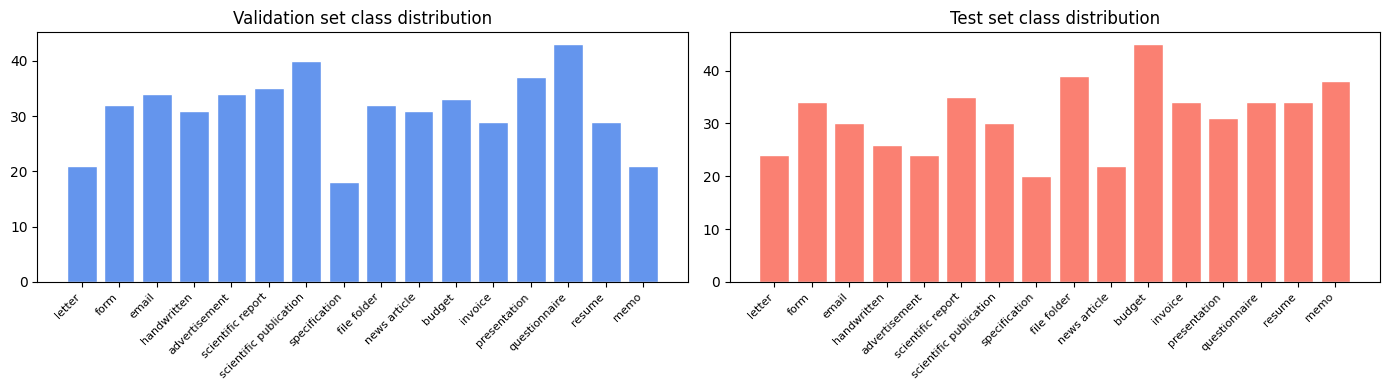

Val and test distribution saved.


In [ ]:
val_labels  = [item['label'] for item in val_list]
test_labels = [item['label'] for item in test_list]

val_counts  = Counter(val_labels)
test_counts = Counter(test_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(
    [LABEL_NAMES[i] for i in sorted(val_counts.keys())],
    [val_counts[i] for i in sorted(val_counts.keys())],
    color='cornflowerblue', edgecolor='white'
)
axes[0].set_title("Validation set class distribution")
axes[0].set_xticklabels(
    [LABEL_NAMES[i] for i in sorted(val_counts.keys())],
    rotation=45, ha='right', fontsize=8
)

axes[1].bar(
    [LABEL_NAMES[i] for i in sorted(test_counts.keys())],
    [test_counts[i] for i in sorted(test_counts.keys())],
    color='salmon', edgecolor='white'
)
axes[1].set_title("Test set class distribution")
axes[1].set_xticklabels(
    [LABEL_NAMES[i] for i in sorted(test_counts.keys())],
    rotation=45, ha='right', fontsize=8
)

plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/val_test_distribution.png", dpi=150)
plt.show()
print("Val and test distribution saved.")

### 12: Dataset Summary Statistics

In [ ]:
total = SUBSET_TRAIN + SUBSET_VAL + SUBSET_TEST

summary = pd.DataFrame({
    'Split'  : ['Train', 'Validation', 'Test'],
    'Samples': [SUBSET_TRAIN, SUBSET_VAL, SUBSET_TEST],
    'Ratio'  : [f"{SUBSET_TRAIN/total*100:.0f}%",
                f"{SUBSET_VAL/total*100:.0f}%",
                f"{SUBSET_TEST/total*100:.0f}%"],
    'Classes': [NUM_CLASSES, NUM_CLASSES, NUM_CLASSES]
})

print("=" * 45)
print("DATASET SUMMARY — RVL-CDIP SUBSET")
print("=" * 45)
print(summary.to_string(index=False))
print("=" * 45)
print(f"Total samples : {total}")
print(f"Num classes   : {NUM_CLASSES}")
print(f"Random seed   : {SEED}")
print(f"Image size    : {IMG_SIZE}")
print("=" * 45)

summary.to_csv(f"{BASE}/outputs/results/dataset_summary.csv", index=False)
print("Summary saved to outputs/results/dataset_summary.csv")

DATASET SUMMARY — RVL-CDIP SUBSET
     Split  Samples Ratio  Classes
     Train     4000   80%       16
Validation      500   10%       16
      Test      500   10%       16
Total samples : 5000
Num classes   : 16
Random seed   : 42
Image size    : (224, 224)
Summary saved to outputs/results/dataset_summary.csv
